# LightGBM + FraudNet ensemble

This notebook asks whether FraudNet adds useful signal to the LightGBM baseline on the IEEE-CIS fraud data. I use the same chronological split as the earlier notebooks: days 1–122 for the first training run, days 123–152 as a gap, and days 153–182 for weight selection. Then I retrain fresh base models for the test set. LightGBM keeps the gap excluded; FraudNet uses all labeled days. Both branches keep every `C1`–`C14` feature.

The three submissions are logistic regression on the two probabilities, a blend of its normalized coefficients, and a blend chosen by validation ROC-AUC. The validation scores below are **selection scores**: this same period guides LightGBM early stopping and the ensemble weights.

## Setup and data

Run this in Colab with access to the [IEEE-CIS competition](https://www.kaggle.com/competitions/ieee-fraud-detection). Choose a GPU runtime for FraudNet. If the five competition CSV files are already in `data/`, the download cell skips Kaggle authentication. Set `USE_WANDB = False` if you do not want experiment logging. `SMOKE_TEST` exercises the pipeline on a small subset and writes to a separate folder; leave it `False` for assignment submissions.

In [1]:
import sys
import subprocess

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "lightgbm", "wandb", "kaggle"],
    check=True,
)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'lightgbm', 'wandb', 'kaggle'], returncode=0)

In [2]:
import gc
import json
import random
import warnings
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import wandb
from IPython.display import display
from pandas.api.types import CategoricalDtype
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score
from sklearn.preprocessing import QuantileTransformer
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
SMOKE_TEST = False
USE_WANDB = True
DATA_DIR = Path("data")
OUTPUT_DIR = Path("csv_ensemble_smoke" if SMOKE_TEST else "csv_ensemble")
WANDB_PROJECT = "ieee-fraud-detection"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"Device: {DEVICE}; smoke test: {SMOKE_TEST}")

if USE_WANDB:
    wandb.login()

Device: cuda; smoke test: False


/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 1


wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: After creating your account, create a new API key and store it securely.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: hhavva (models-kyiv-school-of-economics) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
required_files = [
    "train_transaction.csv",
    "train_identity.csv",
    "test_transaction.csv",
    "test_identity.csv",
    "sample_submission.csv",
]
if not all((DATA_DIR / name).exists() for name in required_files):
    from google.colab import files

    credential_path = Path.home() / ".kaggle" / "kaggle.json"
    if not credential_path.exists():
        print("Upload kaggle.json (the file contents will not be displayed).")
        uploaded = files.upload()
        if "kaggle.json" not in uploaded:
            raise FileNotFoundError("kaggle.json was not uploaded")
        credential_path.parent.mkdir(parents=True, exist_ok=True)
        credential_path.write_bytes(uploaded["kaggle.json"])
        credential_path.chmod(0o600)
        del uploaded

    DATA_DIR.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        ["kaggle", "competitions", "download", "-c", "ieee-fraud-detection"], check=True
    )
    with zipfile.ZipFile("ieee-fraud-detection.zip") as archive:
        archive.extractall(DATA_DIR)

missing_files = [name for name in required_files if not (DATA_DIR / name).exists()]
if missing_files:
    raise FileNotFoundError(f"Missing competition files: {missing_files}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Upload kaggle.json (the file contents will not be displayed).


Saving kaggle.json to kaggle.json


In [4]:
def load_transactions(data_dir, split):
    """Left-join identity records without changing transaction order or row count."""
    transactions = pd.read_csv(data_dir / f"{split}_transaction.csv")
    identity = pd.read_csv(data_dir / f"{split}_identity.csv")
    if not transactions.TransactionID.is_unique or not identity.TransactionID.is_unique:
        raise ValueError(f"Duplicate TransactionID in {split} input")
    merged = transactions.merge(
        identity, on="TransactionID", how="left", validate="one_to_one", sort=False
    )
    if len(merged) != len(transactions) or not merged.TransactionID.equals(
        transactions.TransactionID
    ):
        raise ValueError(f"The {split} identity merge changed transaction order")
    merged.columns = merged.columns.str.replace("-", "_", regex=False)
    float_columns = merged.select_dtypes(include="float64").columns
    merged[float_columns] = merged[float_columns].astype(np.float32)
    merged["DT_day"] = (merged["TransactionDT"] // 86400).astype(np.int16)
    return merged


labeled_df = load_transactions(DATA_DIR, "train")
test_df = load_transactions(DATA_DIR, "test")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")
if not sample_submission.TransactionID.is_unique or not test_df.TransactionID.is_unique:
    raise ValueError("Test or sample-submission IDs are not unique")
if set(sample_submission.TransactionID) != set(test_df.TransactionID):
    raise ValueError("Sample-submission IDs differ from test IDs")
if (int(labeled_df.DT_day.min()), int(labeled_df.DT_day.max())) != (1, 182):
    raise ValueError("Expected labeled data to span days 1–182")
if labeled_df.isFraud.isna().any() or set(labeled_df.isFraud.unique()) != {0, 1}:
    raise ValueError("Training labels must contain both binary classes")

train_mask = labeled_df.DT_day.le(122)
gap_mask = labeled_df.DT_day.between(123, 152)
validation_mask = labeled_df.DT_day.between(153, 182)
if not (train_mask | gap_mask | validation_mask).all():
    raise ValueError("A labeled row falls outside the intended split")
train_df = labeled_df.loc[train_mask]
validation_df = labeled_df.loc[validation_mask]
final_lgbm_mask = train_mask | validation_mask
if validation_df.isFraud.nunique() != 2:
    raise ValueError("Validation needs both classes for ROC-AUC")
split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "days": "1–122",
            "rows": len(train_df),
            "fraud_rate": train_df.isFraud.mean(),
        },
        {
            "split": "gap",
            "days": "123–152",
            "rows": int(gap_mask.sum()),
            "fraud_rate": labeled_df.loc[gap_mask, "isFraud"].mean(),
        },
        {
            "split": "validation",
            "days": "153–182",
            "rows": len(validation_df),
            "fraud_rate": validation_df.isFraud.mean(),
        },
    ]
)
display(split_summary)

if SMOKE_TEST:
    # Keep the day boundaries; sample within each region so the wiring can run cheaply.
    def smoke_sample(frame, limit):
        if len(frame) <= limit:
            return frame
        groups = []
        for _, group in frame.groupby("isFraud"):
            count = min(len(group), max(1, round(limit * len(group) / len(frame))))
            groups.append(group.sample(n=count, random_state=SEED))
        return pd.concat(groups).sort_index()

    train_df = smoke_sample(train_df, 12_000)
    validation_df = smoke_sample(validation_df, 3_000)
    final_lgbm_df = pd.concat([train_df, validation_df], axis=0).sort_index()
    final_fraudnet_df = pd.concat(
        [
            final_lgbm_df,
            smoke_sample(labeled_df.loc[gap_mask], 3_000),
        ],
        axis=0,
    ).sort_index()
    test_df = test_df.head(9_001).copy()
    sample_submission = sample_submission[
        sample_submission.TransactionID.isin(test_df.TransactionID)
    ].copy()
else:
    final_lgbm_df = labeled_df.loc[final_lgbm_mask]
    final_fraudnet_df = labeled_df

assert set(train_df.TransactionID).isdisjoint(validation_df.TransactionID)
assert set(final_lgbm_df.TransactionID) == set(train_df.TransactionID) | set(
    validation_df.TransactionID
)
assert not final_lgbm_df.DT_day.between(123, 152).any()
if not SMOKE_TEST:
    assert set(final_fraudnet_df.TransactionID) == set(labeled_df.TransactionID)
    assert int(final_fraudnet_df.DT_day.between(123, 152).sum()) == int(gap_mask.sum())
else:
    assert set(final_lgbm_df.TransactionID).issubset(final_fraudnet_df.TransactionID)
    assert final_fraudnet_df.DT_day.between(123, 152).any()

/tmp/ipykernel_2847/3564739367.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged["DT_day"] = (merged["TransactionDT"] // 86400).astype(np.int16)
/tmp/ipykernel_2847/3564739367.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged["DT_day"] = (merged["TransactionDT"] // 86400).astype(np.int16)


,split,days,rows,fraud_rate
0,train,1–122,420066,0.035197
1,gap,123–152,85044,0.033912
2,validation,153–182,85430,0.035046


## Training 1: LightGBM

The split above happens before any fitted feature engineering. Frequency maps and category codes below are learned only from days 1–122. Missing and unseen categories have separate codes; the same category levels and feature order are used for validation and test. LightGBM can handle missing numeric values directly.

In [5]:
FREQUENCY_COLUMNS = ["card1", "addr1", "P_emaildomain", "DeviceInfo"]
C_COLUMNS = [f"C{i}" for i in range(1, 15)]
ML_DETREND_COLUMNS = ["D11", "D1", "D15", "D4", "D10", "D2"]
EXCLUDED_ML_COLUMNS = {"isFraud", "TransactionID", "TransactionDT", "DT_day"}


class MLPreprocessor:
    def fit(self, frame):
        self.frequency_maps = {
            column: frame[column].value_counts(dropna=False)
            for column in FREQUENCY_COLUMNS
        }
        self.category_maps = {}
        for column in frame.select_dtypes(include="object").columns:
            values = frame[column].dropna().unique()
            self.category_maps[column] = {
                value: code + 2 for code, value in enumerate(values)
            }
        self.category_dtypes = {
            column: CategoricalDtype(categories=list(range(len(mapping) + 2)))
            for column, mapping in self.category_maps.items()
        }
        features = self._build_features(frame)
        self.feature_columns = features.columns.tolist()
        if any(column not in self.feature_columns for column in C_COLUMNS):
            raise ValueError("LightGBM is missing a C column")
        return self

    def _build_features(self, frame):
        features = frame.drop(columns=list(EXCLUDED_ML_COLUMNS), errors="ignore").copy()
        features["DT_hour"] = frame.TransactionDT // 3600 % 24
        features["DT_dow"] = frame.DT_day % 7
        amount = frame.TransactionAmt
        if amount.isna().any() or (amount < 0).any():
            raise ValueError("TransactionAmt must be present and nonnegative")
        features["TransactionAmt_log"] = np.log1p(amount)
        features["TransactionAmt_decimal"] = (
            (amount - amount.astype(np.int64)) * 1000
        ).astype(np.int32)
        for column in ML_DETREND_COLUMNS:
            features[f"{column}_detrended"] = (
                frame[column] - frame.TransactionDT / 86400
            )
        for column, counts in self.frequency_maps.items():
            features[f"{column}_freq"] = (
                frame[column].map(counts).fillna(0).astype(np.float32)
            )
        for column, mapping in self.category_maps.items():
            codes = frame[column].map(mapping).fillna(1).astype(np.int32)
            codes.loc[frame[column].isna()] = 0
            features[column] = codes.astype(self.category_dtypes[column])
        unexpected_objects = features.select_dtypes(include="object").columns.tolist()
        if unexpected_objects:
            raise ValueError(f"Unencoded ML columns: {unexpected_objects}")
        return features

    def transform(self, frame):
        features = self._build_features(frame)
        if features.columns.tolist() != self.feature_columns:
            raise ValueError("LightGBM feature order changed")
        return features


LGBM_PARAMS = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 64,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.7,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "n_estimators": 1000,
    "random_state": SEED,
    "n_jobs": -1,
}


def train_lightgbm(
    train_features,
    train_target,
    validation_features=None,
    validation_target=None,
    n_estimators=None,
):
    params = {**LGBM_PARAMS}
    if n_estimators is not None:
        params["n_estimators"] = n_estimators
    model = lgb.LGBMClassifier(**params)
    if validation_features is None:
        model.fit(train_features, train_target)
    else:
        model.fit(
            train_features,
            train_target,
            eval_set=[(validation_features, validation_target)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
        )
    return model

In [6]:
holdout_lgbm_params = {
    **LGBM_PARAMS,
    "n_estimators": 40 if SMOKE_TEST else LGBM_PARAMS["n_estimators"],
}
ml_preprocessor = MLPreprocessor().fit(train_df)
holdout_ml_feature_columns = tuple(ml_preprocessor.feature_columns)
ml_train_features = ml_preprocessor.transform(train_df)
ml_validation_features = ml_preprocessor.transform(validation_df)
assert [column for column in ml_train_features if column in C_COLUMNS] == C_COLUMNS
ml_run = None
if USE_WANDB:
    ml_run = wandb.init(
        project=WANDB_PROJECT,
        group="ensemble",
        name="holdout-lightgbm",
        config={**holdout_lgbm_params, "stage": "weight_discovery", "days": "1-122"},
    )
try:
    lgbm_model = train_lightgbm(
        ml_train_features,
        train_df.isFraud,
        ml_validation_features,
        validation_df.isFraud,
        n_estimators=holdout_lgbm_params["n_estimators"],
    )
    holdout_best_iteration = int(lgbm_model.best_iteration_)
    if holdout_best_iteration < 1:
        raise ValueError("LightGBM did not report a valid best iteration")
    lgbm_validation_probability = lgbm_model.predict_proba(
        ml_validation_features, num_iteration=holdout_best_iteration
    )[:, 1]
    if USE_WANDB:
        wandb.log(
            {
                "best_iteration": holdout_best_iteration,
                "validation_auc": roc_auc_score(
                    validation_df.isFraud, lgbm_validation_probability
                ),
            }
        )
finally:
    if ml_run is not None:
        ml_run.finish()
print("LightGBM best iteration:", holdout_best_iteration)
if holdout_best_iteration == holdout_lgbm_params["n_estimators"]:
    print("The selected iteration reached the training ceiling.")
del ml_train_features, ml_validation_features
gc.collect()

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 14785, number of negative: 405281
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.132763 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 36975
[LightGBM] [Info] Number of data points in the train set: 420066, number of used features: 443
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035197 -> initscore=-3.310968
[LightGBM] [Info] Start training from score -3.310968
[100]	valid_0's auc: 0.902864
[200]	valid_0's auc: 0.909164
[300]	valid_0's auc: 0.911498


best_iteration,▁
validation_auc,▁
best_iteration,311
validation_auc,0.9122


LightGBM best iteration: 311


238

## Training 1: FraudNet

This keeps the feature choices and architecture from `dl.ipynb`, with `C4`, `C7`, `C10`, and `C12` added to the numeric inputs. `NanFill` learns replacements for missing transformed numeric values. The custom `AdamW` applies weight decay separately from its gradient update, as in the assignment notebook. The chosen `lr-high` run trained for four epochs; I use epoch four in both stages.

In [7]:
DL_CATEGORICAL_COLUMNS = (
    [
        "ProductCD",
        "card1",
        "card2",
        "card3",
        "card4",
        "card5",
        "card6",
        "addr1",
        "addr2",
        "P_emaildomain",
        "R_emaildomain",
        "DeviceType",
        "DeviceInfo",
        "DT_hour",
        "DT_dow",
    ]
    + [f"M{i}" for i in range(1, 10)]
    + [f"id_{i}" for i in range(12, 39)]
)
DL_NUMERIC_COLUMNS = (
    ["TransactionAmt", "TransactionAmt_decimal", "dist1", "dist2"]
    + C_COLUMNS
    + ["D3", "D5", "D6", "D7", "D8", "D9", "D12", "D13", "D14"]
    + [f"D{i}_detrended" for i in (1, 2, 4, 10, 11, 15)]
    + [f"V{i}" for i in range(1, 340)]
    + [f"id_{i:02d}" for i in range(1, 12)]
)
assert len(DL_NUMERIC_COLUMNS) == len(set(DL_NUMERIC_COLUMNS))
assert [column for column in DL_NUMERIC_COLUMNS if column in C_COLUMNS] == C_COLUMNS


class DLPreprocessor:
    def __init__(self, categorical_columns, numeric_columns, frequency_columns):
        self.categorical_columns = list(categorical_columns)
        self.numeric_columns = list(numeric_columns)
        self.frequency_columns = list(frequency_columns)
        computed = {"DT_hour", "DT_dow", "TransactionAmt_decimal"}
        computed.update(f"D{i}_detrended" for i in (1, 2, 4, 10, 11, 15))
        raw_features = (
            self.categorical_columns + self.numeric_columns + self.frequency_columns
        )
        self.raw_columns = list(
            dict.fromkeys(
                [column for column in raw_features if column not in computed]
                + ["D1", "D2", "D4", "D10", "D11", "D15", "TransactionDT", "DT_day"]
            )
        )

    def _derived(self, frame):
        derived = frame[self.raw_columns].copy()
        derived["DT_hour"] = frame.TransactionDT // 3600 % 24
        derived["DT_dow"] = frame.DT_day % 7
        derived["TransactionAmt_decimal"] = np.round(frame.TransactionAmt % 1 * 1000)
        for column in ("D1", "D2", "D4", "D10", "D11", "D15"):
            derived[f"{column}_detrended"] = frame[column] - frame.TransactionDT / 86400
        return derived

    def fit(self, frame):
        derived = self._derived(frame)
        required = (
            self.categorical_columns + self.numeric_columns + self.frequency_columns
        )
        missing = set(required) - set(derived.columns)
        if missing:
            raise ValueError(f"Missing FraudNet features: {sorted(missing)}")
        self.frequency_maps = {
            column: derived[column].value_counts(dropna=False)
            for column in self.frequency_columns
        }
        self.category_maps = {}
        for column in self.categorical_columns:
            counts = derived[column].value_counts(dropna=True)
            frequent_values = counts[counts >= 10].index
            self.category_maps[column] = {
                value: code + 2 for code, value in enumerate(frequent_values)
            }
        self.embedding_sizes = [
            len(self.category_maps[column]) + 2 for column in self.categorical_columns
        ]
        numeric = self._numeric(derived)
        self.quantile_transformer = QuantileTransformer(
            n_quantiles=min(1000, len(frame)),
            output_distribution="normal",
            subsample=200_000,
            random_state=0,
        )
        self.quantile_transformer.fit(numeric)
        return self

    def _numeric(self, derived):
        # The final four columns are the train-fitted frequency encodings.
        numeric = derived[self.numeric_columns].to_numpy(dtype=np.float32, copy=True)
        frequencies = np.column_stack(
            [
                derived[column]
                .map(self.frequency_maps[column])
                .fillna(0)
                .to_numpy(np.float32)
                for column in self.frequency_columns
            ]
        )
        return np.concatenate([numeric, frequencies], axis=1)

    def transform(self, frame):
        derived = self._derived(frame)
        x_numeric = self.quantile_transformer.transform(self._numeric(derived)).astype(
            np.float32, copy=False
        )
        x_categorical = np.empty(
            (len(frame), len(self.categorical_columns)), dtype=np.int64
        )
        for index, column in enumerate(self.categorical_columns):
            codes = (
                derived[column]
                .map(self.category_maps[column])
                .fillna(1)
                .to_numpy(dtype=np.int64, copy=True)
            )
            codes[derived[column].isna().to_numpy()] = 0
            if codes.max(initial=0) >= self.embedding_sizes[index]:
                raise ValueError(f"Invalid embedding code for {column}")
            x_categorical[:, index] = codes
        if np.isinf(x_numeric).any():
            raise ValueError("FraudNet numeric features contain infinity")
        return x_numeric, x_categorical


def new_dl_preprocessor():
    return DLPreprocessor(DL_CATEGORICAL_COLUMNS, DL_NUMERIC_COLUMNS, FREQUENCY_COLUMNS)

In [8]:
class NanFill(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.fill = nn.Parameter(torch.zeros(n_features))

    def forward(self, numeric):
        return torch.where(torch.isnan(numeric), self.fill, numeric)


class FraudNet(nn.Module):
    def __init__(self, numeric_features, embedding_sizes, hidden=512, dropout=0.2):
        super().__init__()
        self.nan_fill = NanFill(numeric_features)
        self.embeddings = nn.ModuleList(
            [nn.Embedding(size, 8) for size in embedding_sizes]
        )
        input_width = numeric_features + 8 * len(embedding_sizes)
        self.layers = nn.Sequential(
            nn.Linear(input_width, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, hidden // 4),
            nn.BatchNorm1d(hidden // 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 4, 1),
        )

    def forward(self, numeric, categorical):
        parts = [self.nan_fill(numeric)]
        parts.extend(
            embedding(categorical[:, index])
            for index, embedding in enumerate(self.embeddings)
        )
        return self.layers(torch.cat(parts, dim=1)).squeeze(1)


class AdamW(torch.optim.Optimizer):
    def __init__(
        self, parameters, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=1e-2
    ):
        super().__init__(
            parameters, dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay)
        )

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()
        for group in self.param_groups:
            learning_rate = group["lr"]
            beta1, beta2 = group["betas"]
            for parameter in group["params"]:
                if parameter.grad is None:
                    continue
                gradient = parameter.grad
                state = self.state[parameter]
                if not state:
                    state["step"] = 0
                    state["first_moment"] = torch.zeros_like(parameter)
                    state["second_moment"] = torch.zeros_like(parameter)
                state["step"] += 1
                parameter.mul_(1 - learning_rate * group["weight_decay"])
                first = state["first_moment"]
                second = state["second_moment"]
                first.mul_(beta1).add_(gradient, alpha=1 - beta1)
                second.mul_(beta2).addcmul_(gradient, gradient, value=1 - beta2)
                corrected_first = first / (1 - beta1 ** state["step"])
                corrected_second = second / (1 - beta2 ** state["step"])
                parameter.addcdiv_(
                    corrected_first,
                    corrected_second.sqrt().add(group["eps"]),
                    value=-learning_rate,
                )
        return loss


FRAUDNET_CONFIG = {
    "learning_rate": 0.004,
    "weight_decay": 0.01,
    "hidden": 512,
    "dropout": 0.2,
    "epochs": 4,
    "batch_size": 2048,
    "inference_batch_size": 8192,
    "scheduler_gamma": 0.8,
}

In [9]:
def predict_fraudnet(model, numeric, categorical, device, batch_size=8192):
    if len(numeric) != len(categorical):
        raise ValueError("FraudNet inference arrays have different lengths")
    model.eval()
    predictions = []
    with torch.inference_mode():
        for start in range(0, len(numeric), batch_size):
            stop = start + batch_size
            logits = model(
                torch.from_numpy(numeric[start:stop]).to(device),
                torch.from_numpy(categorical[start:stop]).to(device),
            )
            predictions.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(predictions) if predictions else np.empty(0, dtype=np.float32)


def train_fraudnet(
    train_data,
    embedding_sizes,
    device,
    config,
    validation_data=None,
    run_name=None,
    training_days=None,
):
    """Create a fresh network, optimizer, and scheduler; use exactly config["epochs"] epochs."""
    numeric, categorical, labels = train_data
    if len(numeric) < config["batch_size"]:
        raise ValueError("FraudNet needs at least one full training batch")
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    generator = torch.Generator().manual_seed(SEED)
    dataset = TensorDataset(
        torch.from_numpy(numeric),
        torch.from_numpy(categorical),
        torch.from_numpy(labels),
    )
    loader = DataLoader(
        dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        drop_last=True,
        generator=generator,
    )
    model = FraudNet(
        numeric.shape[1],
        embedding_sizes,
        hidden=config["hidden"],
        dropout=config["dropout"],
    ).to(device)
    optimizer = AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ExponentialLR(
        optimizer, gamma=config["scheduler_gamma"]
    )
    criterion = nn.BCEWithLogitsLoss()
    history = []
    run = None
    if USE_WANDB:
        run = wandb.init(
            project=WANDB_PROJECT,
            group="ensemble",
            name=run_name,
            config={**config, "device": str(device), "training_days": training_days},
        )
    try:
        for epoch in range(1, config["epochs"] + 1):
            model.train()
            total_loss = 0.0
            for batch_numeric, batch_categorical, batch_labels in loader:
                optimizer.zero_grad()
                logits = model(batch_numeric.to(device), batch_categorical.to(device))
                loss = criterion(logits, batch_labels.to(device))
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            row = {
                "epoch": epoch,
                "train_loss": total_loss / len(loader),
                "learning_rate": optimizer.param_groups[0]["lr"],
            }
            if validation_data is not None:
                val_numeric, val_categorical, val_labels = validation_data
                probabilities = predict_fraudnet(
                    model,
                    val_numeric,
                    val_categorical,
                    device,
                    config["inference_batch_size"],
                )
                row["validation_auc"] = roc_auc_score(val_labels, probabilities)
                row["validation_ap"] = average_precision_score(
                    val_labels, probabilities
                )
                row["validation_log_loss"] = log_loss(val_labels, probabilities)
            history.append(row)
            if USE_WANDB:
                wandb.log(row)
            print(row)
            scheduler.step()
    finally:
        if run is not None:
            run.finish()
    return model, pd.DataFrame(history)


def predict_fraudnet_frame(model, preprocessor, frame, device, row_batch_size=32_768):
    """Transform and infer in chunks, including the final partial chunk."""
    chunks = []
    for start in range(0, len(frame), row_batch_size):
        numeric, categorical = preprocessor.transform(
            frame.iloc[start : start + row_batch_size]
        )
        chunks.append(predict_fraudnet(model, numeric, categorical, device))
    return np.concatenate(chunks) if chunks else np.empty(0, dtype=np.float32)

In [10]:
dl_preprocessor = new_dl_preprocessor().fit(train_df)
dl_train_numeric, dl_train_categorical = dl_preprocessor.transform(train_df)
dl_validation_numeric, dl_validation_categorical = dl_preprocessor.transform(
    validation_df
)
assert all(column in dl_preprocessor.numeric_columns for column in C_COLUMNS)
dl_config = {**FRAUDNET_CONFIG, "epochs": (1 if SMOKE_TEST else 4)}
fraudnet_model, fraudnet_history = train_fraudnet(
    (dl_train_numeric, dl_train_categorical, train_df.isFraud.to_numpy(np.float32)),
    dl_preprocessor.embedding_sizes,
    DEVICE,
    dl_config,
    validation_data=(
        dl_validation_numeric,
        dl_validation_categorical,
        validation_df.isFraud.to_numpy(np.float32),
    ),
    run_name="holdout-fraudnet",
    training_days="1-122",
)
fraudnet_validation_probability = predict_fraudnet(
    fraudnet_model, dl_validation_numeric, dl_validation_categorical, DEVICE
)
del (
    dl_train_numeric,
    dl_train_categorical,
    dl_validation_numeric,
    dl_validation_categorical,
)
gc.collect()
display(fraudnet_history)

{'epoch': 1, 'train_loss': 0.11492619154656805, 'learning_rate': 0.004, 'validation_auc': np.float64(0.8616757813263483), 'validation_ap': np.float64(0.41201460526476963), 'validation_log_loss': 0.1209899726060223}
{'epoch': 2, 'train_loss': 0.08767789567752582, 'learning_rate': 0.0032, 'validation_auc': np.float64(0.872669737391551), 'validation_ap': np.float64(0.42219805282571626), 'validation_log_loss': 0.13496276824087935}
{'epoch': 3, 'train_loss': 0.0796117509828835, 'learning_rate': 0.00256, 'validation_auc': np.float64(0.8616749385843678), 'validation_ap': np.float64(0.4179203970799516), 'validation_log_loss': 0.13722257475636065}
{'epoch': 4, 'train_loss': 0.07371561123830517, 'learning_rate': 0.0020480000000000003, 'validation_auc': np.float64(0.8760951107902641), 'validation_ap': np.float64(0.412135609197393), 'validation_log_loss': 0.12310336693158}


epoch,▁▃▆█
learning_rate,█▅▃▁
train_loss,█▃▂▁
validation_ap,▁█▅▁
validation_auc,▁▆▁█
validation_log_loss,▁▇█▂
epoch,4
learning_rate,0.00205
train_loss,0.07372
validation_ap,0.41214
validation_auc,0.8761


,epoch,train_loss,learning_rate,validation_auc,validation_ap,validation_log_loss
0,1,0.114926,0.004000,0.861676,0.412015,0.120990
1,2,0.087678,0.003200,0.872670,0.422198,0.134963
2,3,0.079612,0.002560,0.861675,0.417920,0.137223
3,4,0.073716,0.002048,0.876095,0.412136,0.123103


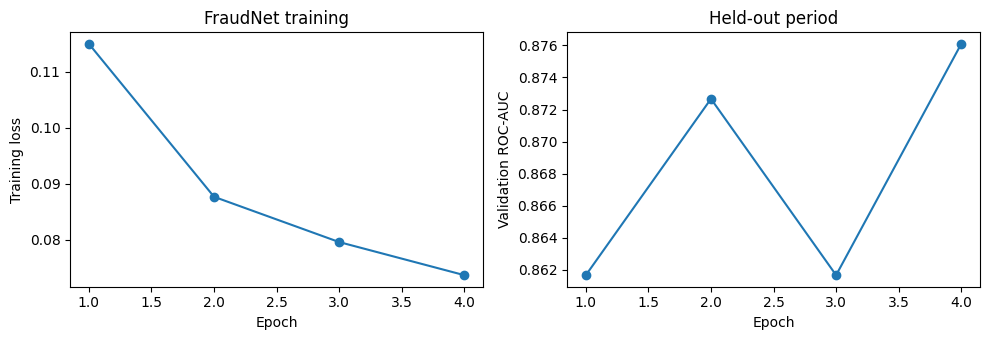

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(fraudnet_history.epoch, fraudnet_history.train_loss, marker="o")
axes[0].set(xlabel="Epoch", ylabel="Training loss", title="FraudNet training")
axes[1].plot(fraudnet_history.epoch, fraudnet_history.validation_auc, marker="o")
axes[1].set(xlabel="Epoch", ylabel="Validation ROC-AUC", title="Held-out period")
plt.tight_layout()
plt.show()

## Validation predictions and weight selection

The two prediction columns are joined by `TransactionID`, with the validation frame determining row order. Average precision (AP) is reported alongside ROC-AUC. The 50/50 blend is a simple reference, not another fitted model.

In [12]:
def align_predictions(reference, prediction_frames):
    """Return one prediction row per reference ID, in reference order."""
    if not reference.TransactionID.is_unique:
        raise ValueError("Reference IDs are not unique")
    aligned = reference[["TransactionID"]].copy()
    for prediction_frame in prediction_frames:
        if not prediction_frame.TransactionID.is_unique:
            raise ValueError("Prediction IDs are not unique")
        if set(prediction_frame.TransactionID) != set(reference.TransactionID):
            raise ValueError("Prediction IDs do not match the reference IDs")
        aligned = aligned.merge(
            prediction_frame,
            on="TransactionID",
            how="left",
            validate="one_to_one",
            sort=False,
        )
    if not aligned.TransactionID.equals(reference.TransactionID.reset_index(drop=True)):
        raise ValueError("Prediction alignment changed ID order")
    return aligned


def evaluate_predictions(labels, probabilities):
    probabilities = np.asarray(probabilities)
    if len(labels) != len(probabilities) or not np.isfinite(probabilities).all():
        raise ValueError("Invalid evaluation probabilities")
    if ((probabilities < 0) | (probabilities > 1)).any():
        raise ValueError("Probabilities must lie in [0, 1]")
    return {
        "roc_auc": roc_auc_score(labels, probabilities),
        "average_precision": average_precision_score(labels, probabilities),
    }


validation_predictions = align_predictions(
    validation_df,
    [
        pd.DataFrame(
            {
                "TransactionID": validation_df.TransactionID.to_numpy(),
                "lgbm_probability": lgbm_validation_probability,
            }
        ),
        pd.DataFrame(
            {
                "TransactionID": validation_df.TransactionID.to_numpy(),
                "fraudnet_probability": fraudnet_validation_probability,
            }
        ),
    ],
)
validation_predictions.insert(1, "isFraud", validation_df.isFraud.to_numpy())
META_COLUMNS = ["lgbm_probability", "fraudnet_probability"]
meta_validation_features = validation_predictions[META_COLUMNS]
validation_labels = validation_predictions.isFraud.to_numpy()

selection_scores = {}
for name, probabilities in {
    "LightGBM": validation_predictions.lgbm_probability,
    "FraudNet": validation_predictions.fraudnet_probability,
    "50/50": meta_validation_features.mean(axis=1),
}.items():
    selection_scores[name] = evaluate_predictions(validation_labels, probabilities)

correlation = meta_validation_features.corr().iloc[0, 1]
print(f"Validation probability correlation: {correlation:.3f}")
display(pd.DataFrame(selection_scores).T)

Validation probability correlation: 0.734


,roc_auc,average_precision
LightGBM,0.912203,0.549821
FraudNet,0.876095,0.412136
50/50,0.903228,0.497820


Logistic regression warning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.


,method,roc_auc,average_precision
0,LightGBM,0.912203,0.549821
1,FraudNet,0.876095,0.412136
2,50/50,0.903228,0.497820
3,LR stacking,0.909049,0.527164
4,LR weights,0.909049,0.527164
5,AUC search,0.913007,0.548905


LR coefficients: {'lgbm_probability': np.float64(5.49461086297051), 'fraudnet_probability': np.float64(2.121792610875166)}
LR intercept: -4.166238612882201
Normalized LR weights: [0.72141804 0.27858196]
AUC search weights: [0.96 0.04]
LR convergence iterations: [13]
LR converged: True


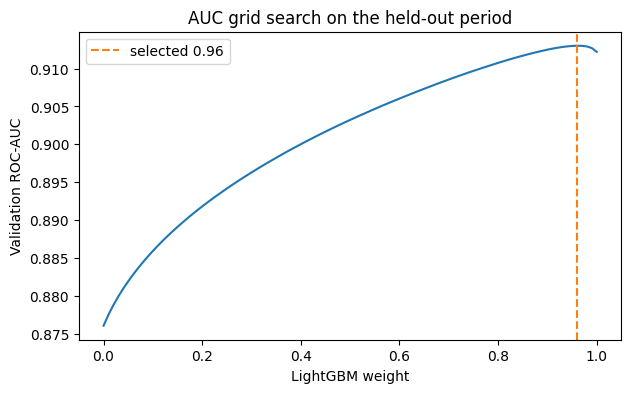

In [13]:
def normalize_blend_weights(coefficients):
    """Turn two nonnegative LR coefficients into convex blend weights."""
    coefficients = np.asarray(coefficients, dtype=np.float64).reshape(-1)
    if coefficients.shape != (2,) or not np.isfinite(coefficients).all():
        raise ValueError("Expected two finite logistic-regression coefficients")
    coefficient_sum = coefficients.sum()
    if (coefficients < 0).any() or coefficient_sum <= 1e-12:
        raise ValueError(
            "Normalized LR blend requires nonnegative coefficients with positive sum"
        )
    return coefficients / coefficient_sum


def search_blend_weight(labels, lgbm_probabilities, fraudnet_probabilities):
    """Choose highest AUC on a 0.01 grid; exact ties favor LightGBM."""
    rows = []
    for lgbm_weight in np.linspace(0.0, 1.0, 101):
        probabilities = (
            lgbm_weight * lgbm_probabilities
            + (1.0 - lgbm_weight) * fraudnet_probabilities
        )
        rows.append(
            {
                "lgbm_weight": float(lgbm_weight),
                "fraudnet_weight": float(1.0 - lgbm_weight),
                "roc_auc": float(roc_auc_score(labels, probabilities)),
            }
        )
    curve = pd.DataFrame(rows)
    winner = curve.sort_values(
        ["roc_auc", "lgbm_weight"], ascending=[False, False]
    ).iloc[0]
    if winner.roc_auc + 1e-12 < max(curve.roc_auc.iloc[0], curve.roc_auc.iloc[-1]):
        raise AssertionError("AUC search fell below a base-model endpoint")
    return winner, curve


meta_model = LogisticRegression(C=0.1, solver="lbfgs", max_iter=1000, random_state=SEED)
with warnings.catch_warnings(record=True) as fit_warnings:
    warnings.simplefilter("always")
    meta_model.fit(meta_validation_features, validation_labels)
for fit_warning in fit_warnings:
    print(f"Logistic regression warning: {fit_warning.message}")
lr_converged = not any(
    issubclass(item.category, ConvergenceWarning) for item in fit_warnings
)
lr_coefficients = meta_model.coef_[0].astype(np.float64, copy=True)
lr_intercept = float(meta_model.intercept_[0])
normalized_weights = None
normalized_weight_status = "valid"
try:
    normalized_weights = normalize_blend_weights(lr_coefficients)
except ValueError as error:
    normalized_weight_status = str(error)
    print("Method B unavailable:", normalized_weight_status)

best_blend_row, blend_weight_search = search_blend_weight(
    validation_labels,
    validation_predictions.lgbm_probability.to_numpy(),
    validation_predictions.fraudnet_probability.to_numpy(),
)
auc_search_weights = np.array(
    [
        best_blend_row.lgbm_weight,
        best_blend_row.fraudnet_weight,
    ],
    dtype=np.float64,
)

selection_scores["LR stacking"] = evaluate_predictions(
    validation_labels, meta_model.predict_proba(meta_validation_features)[:, 1]
)
if normalized_weights is not None:
    selection_scores["LR weights"] = evaluate_predictions(
        validation_labels,
        meta_validation_features.to_numpy() @ normalized_weights,
    )
selection_scores["AUC search"] = evaluate_predictions(
    validation_labels,
    meta_validation_features.to_numpy() @ auc_search_weights,
)
validation_metrics = (
    pd.DataFrame(selection_scores).T.rename_axis("method").reset_index()
)
display(validation_metrics)
print("LR coefficients:", dict(zip(META_COLUMNS, lr_coefficients)))
print("LR intercept:", lr_intercept)
print("Normalized LR weights:", normalized_weights)
print("AUC search weights:", auc_search_weights)
print("LR convergence iterations:", meta_model.n_iter_)
print("LR converged:", lr_converged)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(blend_weight_search.lgbm_weight, blend_weight_search.roc_auc)
ax.axvline(
    best_blend_row.lgbm_weight,
    color="tab:orange",
    linestyle="--",
    label=f"selected {best_blend_row.lgbm_weight:.2f}",
)
ax.set(
    xlabel="LightGBM weight",
    ylabel="Validation ROC-AUC",
    title="AUC grid search on the held-out period",
)
ax.legend()
plt.show()

The two LR methods use the same coefficients. When their sum is positive, the logistic sigmoid and intercept preserve the ranking of the weighted sum, so their ROC-AUC and AP should agree except for numerical ties. Their probability values differ. The AUC grid selects ranking performance, not calibration. If the LR coefficients cannot form a nonnegative blend, I report Method B as unavailable rather than clipping or substituting weights.

In [14]:
# Save the weight-discovery state before the longer final training run.
locked_state = {
    "meta_columns": tuple(META_COLUMNS),
    "lr_coefficients": tuple(float(value) for value in lr_coefficients),
    "lr_intercept": lr_intercept,
    "normalized_weights": (
        tuple(float(value) for value in normalized_weights)
        if normalized_weights is not None
        else None
    ),
    "auc_search_weights": tuple(float(value) for value in auc_search_weights),
    "holdout_best_iteration": holdout_best_iteration,
    "lr_class_labels": tuple(int(value) for value in meta_model.classes_),
}
locked_state_path = OUTPUT_DIR / "weight_discovery.json"
meta_model_path = OUTPUT_DIR / "weight_discovery_lr.joblib"
locked_state_path.write_text(json.dumps(locked_state, indent=2) + "\n")
joblib.dump(meta_model, meta_model_path)
if json.loads(locked_state_path.read_text()) != json.loads(json.dumps(locked_state)):
    raise AssertionError("Saved weight-discovery state differs from the fitted state")
saved_meta_model = joblib.load(meta_model_path)
np.testing.assert_array_equal(saved_meta_model.coef_, meta_model.coef_)
np.testing.assert_array_equal(saved_meta_model.intercept_, meta_model.intercept_)
np.testing.assert_array_equal(saved_meta_model.classes_, meta_model.classes_)
del saved_meta_model
validation_predictions.to_csv(OUTPUT_DIR / "validation_predictions.csv", index=False)
validation_metrics.to_csv(OUTPUT_DIR / "validation_metrics.csv", index=False)
blend_weight_search.to_csv(OUTPUT_DIR / "blend_weight_search.csv", index=False)

if USE_WANDB:
    with wandb.init(
        project=WANDB_PROJECT,
        group="ensemble",
        name="weight-discovery",
        config={"meta_columns": META_COLUMNS, "lr_C": 0.1},
    ):
        wandb.log(
            {
                f"selection/{row.method}/roc_auc": row.roc_auc
                for row in validation_metrics.itertuples()
            }
        )
        wandb.log(
            {
                "selected_lgbm_weight": float(auc_search_weights[0]),
                "lr_lgbm_coefficient": float(lr_coefficients[0]),
                "lr_fraudnet_coefficient": float(lr_coefficients[1]),
            }
        )

# Training 2 creates fresh base models and fresh preprocessing state.
del lgbm_model, ml_preprocessor, fraudnet_model, dl_preprocessor
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

lr_fraudnet_coefficient,▁
lr_lgbm_coefficient,▁
selected_lgbm_weight,▁
selection/50/50/roc_auc,▁
selection/AUC search/roc_auc,▁
selection/FraudNet/roc_auc,▁
selection/LR stacking/roc_auc,▁
selection/LR weights/roc_auc,▁
selection/LightGBM/roc_auc,▁
lr_fraudnet_coefficient,2.12179
lr_lgbm_coefficient,5.49461


## Training 2: fresh models for the test set

LightGBM trains on days 1–122 plus 153–182. Its tree count is the held-out best iteration multiplied by 1.1, the heuristic used in `ml.ipynb`; there is no early stopping in this refit. FraudNet trains from new weights on all 182 labeled days, including the gap, for exactly four epochs. Both preprocessors are fitted again on their own final training rows. The blend weights above stay fixed. The selected state and fitted LR are saved before this stage begins.

In [15]:
final_ml_preprocessor = MLPreprocessor().fit(final_lgbm_df)
final_ml_feature_columns = tuple(final_ml_preprocessor.feature_columns)
if final_ml_feature_columns != holdout_ml_feature_columns:
    raise ValueError("LightGBM feature columns changed between training stages")
final_ml_features = final_ml_preprocessor.transform(final_lgbm_df)
assert [column for column in final_ml_features if column in C_COLUMNS] == C_COLUMNS
final_tree_count = max(1, int(1.1 * holdout_best_iteration))
if SMOKE_TEST:
    final_tree_count = min(final_tree_count, 44)
final_lgbm_params = {**LGBM_PARAMS, "n_estimators": final_tree_count}
final_ml_run = None
if USE_WANDB:
    final_ml_run = wandb.init(
        project=WANDB_PROJECT,
        group="ensemble",
        name="final-lightgbm",
        config={
            **final_lgbm_params,
            "stage": "final_inference",
            "days": "1-122,153-182",
        },
    )
try:
    final_lgbm_model = train_lightgbm(
        final_ml_features,
        final_lgbm_df.isFraud,
        n_estimators=final_lgbm_params["n_estimators"],
    )
    if USE_WANDB:
        wandb.log({"train_rows": len(final_lgbm_df), "trees": final_tree_count})
finally:
    if final_ml_run is not None:
        final_ml_run.finish()
del final_ml_features
gc.collect()

lgbm_test_chunks = []
for start in range(0, len(test_df), 50_000):
    features = final_ml_preprocessor.transform(test_df.iloc[start : start + 50_000])
    lgbm_test_chunks.append(final_lgbm_model.predict_proba(features)[:, 1])
    del features
lgbm_test_probability = np.concatenate(lgbm_test_chunks)
del lgbm_test_chunks, final_lgbm_model, final_ml_preprocessor
gc.collect()

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 17779, number of negative: 487717
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.940882 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41678
[LightGBM] [Info] Number of data points in the train set: 505496, number of used features: 444
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035171 -> initscore=-3.311717
[LightGBM] [Info] Start training from score -3.311717


train_rows,▁
trees,▁
train_rows,505496
trees,342


4

In [16]:
final_dl_preprocessor = new_dl_preprocessor().fit(final_fraudnet_df)
final_dl_numeric, final_dl_categorical = final_dl_preprocessor.transform(
    final_fraudnet_df
)
assert all(column in final_dl_preprocessor.numeric_columns for column in C_COLUMNS)
final_fraudnet_model, final_fraudnet_history = train_fraudnet(
    (
        final_dl_numeric,
        final_dl_categorical,
        final_fraudnet_df.isFraud.to_numpy(np.float32),
    ),
    final_dl_preprocessor.embedding_sizes,
    DEVICE,
    dl_config,
    validation_data=None,
    run_name="final-fraudnet",
    training_days="1-182",
)
del final_dl_numeric, final_dl_categorical
gc.collect()
fraudnet_test_probability = predict_fraudnet_frame(
    final_fraudnet_model, final_dl_preprocessor, test_df, DEVICE
)
del final_fraudnet_model, final_dl_preprocessor
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
display(final_fraudnet_history)

{'epoch': 1, 'train_loss': 0.1117194435145292, 'learning_rate': 0.004}
{'epoch': 2, 'train_loss': 0.0855652221168081, 'learning_rate': 0.0032}
{'epoch': 3, 'train_loss': 0.07695292854785091, 'learning_rate': 0.00256}
{'epoch': 4, 'train_loss': 0.07119662361219525, 'learning_rate': 0.0020480000000000003}


epoch,▁▃▆█
learning_rate,█▅▃▁
train_loss,█▃▂▁
epoch,4
learning_rate,0.00205
train_loss,0.0712


,epoch,train_loss,learning_rate
0,1,0.111719,0.004000
1,2,0.085565,0.003200
2,3,0.076953,0.002560
3,4,0.071197,0.002048


## Export and checks

Predictions are aligned to `sample_submission.csv` by ID. The LR model and both weight vectors are checked against their saved values before writing files. No Kaggle submission is made automatically.

In [17]:
if tuple(META_COLUMNS) != locked_state["meta_columns"]:
    raise AssertionError("Meta-feature order changed")
if json.loads(locked_state_path.read_text()) != json.loads(json.dumps(locked_state)):
    raise AssertionError("Saved weight-discovery state changed during final training")
if locked_state["holdout_best_iteration"] != holdout_best_iteration:
    raise AssertionError("The selected LightGBM iteration changed")
np.testing.assert_array_equal(meta_model.coef_[0], locked_state["lr_coefficients"])
np.testing.assert_array_equal(meta_model.intercept_, [locked_state["lr_intercept"]])
export_meta_model = joblib.load(meta_model_path)
np.testing.assert_array_equal(export_meta_model.coef_, meta_model.coef_)
np.testing.assert_array_equal(export_meta_model.intercept_, meta_model.intercept_)
np.testing.assert_array_equal(
    export_meta_model.classes_, locked_state["lr_class_labels"]
)
if tuple(export_meta_model.feature_names_in_) != locked_state["meta_columns"]:
    raise AssertionError("Saved LR feature order changed")
if export_meta_model.classes_.tolist() != [0, 1]:
    raise AssertionError("LR positive-class column is not class 1")
if normalized_weights is not None:
    np.testing.assert_array_equal(
        normalized_weights, locked_state["normalized_weights"]
    )
np.testing.assert_array_equal(auc_search_weights, locked_state["auc_search_weights"])

test_base_predictions = align_predictions(
    sample_submission,
    [
        pd.DataFrame(
            {
                "TransactionID": test_df.TransactionID.to_numpy(),
                "lgbm_probability": lgbm_test_probability,
            }
        ),
        pd.DataFrame(
            {
                "TransactionID": test_df.TransactionID.to_numpy(),
                "fraudnet_probability": fraudnet_test_probability,
            }
        ),
    ],
)
meta_test_features = test_base_predictions[list(locked_state["meta_columns"])]
if not np.isfinite(meta_test_features.to_numpy()).all():
    raise ValueError("Base-model test probabilities contain non-finite values")
if ((meta_test_features.to_numpy() < 0) | (meta_test_features.to_numpy() > 1)).any():
    raise ValueError("Base-model test probabilities must lie in [0, 1]")
test_base_predictions.to_csv(OUTPUT_DIR / "test_base_predictions.csv", index=False)


def make_submission(reference, probabilities, path):
    """Validate the competition schema and read the saved file back."""
    probabilities = np.asarray(probabilities)
    if probabilities.shape != (len(reference),) or not np.isfinite(probabilities).all():
        raise ValueError(f"Invalid submission probabilities for {path.name}")
    if ((probabilities < 0) | (probabilities > 1)).any():
        raise ValueError(f"Submission probabilities outside [0, 1]: {path.name}")
    submission = pd.DataFrame(
        {
            "TransactionID": reference.TransactionID.to_numpy(),
            "isFraud": probabilities,
        }
    )
    if not submission.TransactionID.is_unique:
        raise ValueError("Submission IDs are not unique")
    submission.to_csv(path, index=False)
    saved = pd.read_csv(path)
    if saved.columns.tolist() != ["TransactionID", "isFraud"]:
        raise AssertionError("Saved submission schema changed")
    if len(saved) != len(reference) or not saved.TransactionID.equals(
        reference.TransactionID.reset_index(drop=True)
    ):
        raise AssertionError("Saved submission IDs changed")
    if not np.isfinite(saved.isFraud).all() or not saved.isFraud.between(0, 1).all():
        raise AssertionError("Saved submission probabilities are invalid")
    return path


submission_files = [
    make_submission(
        sample_submission,
        export_meta_model.predict_proba(meta_test_features)[:, 1],
        OUTPUT_DIR / "submission_ensemble_lr.csv",
    )
]
if normalized_weights is None:
    previous_method_b = OUTPUT_DIR / "submission_ensemble_lr_weights.csv"
    if previous_method_b.exists():
        timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
        archive_path = (
            OUTPUT_DIR / f"submission_ensemble_lr_weights_previous_{timestamp}.csv"
        )
        previous_method_b.rename(archive_path)
        print("Archived a Method B file from an earlier run:", archive_path)
if normalized_weights is not None:
    submission_files.append(
        make_submission(
            sample_submission,
            meta_test_features.to_numpy() @ normalized_weights,
            OUTPUT_DIR / "submission_ensemble_lr_weights.csv",
        )
    )
submission_files.append(
    make_submission(
        sample_submission,
        meta_test_features.to_numpy() @ auc_search_weights,
        OUTPUT_DIR / "submission_ensemble_auc_search.csv",
    )
)
print("Saved submissions:", [str(path) for path in submission_files])

Saved submissions: ['csv_ensemble/submission_ensemble_lr.csv', 'csv_ensemble/submission_ensemble_lr_weights.csv', 'csv_ensemble/submission_ensemble_auc_search.csv']


In [18]:
run_metadata = {
    "mode": "smoke" if SMOKE_TEST else "full",
    "seed": SEED,
    "device": str(DEVICE),
    "versions": {
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "lightgbm": lgb.__version__,
        "torch": torch.__version__,
        "wandb": wandb.__version__,
    },
    "training_1": {
        "lightgbm": {
            "days": "1-122",
            "rows": len(train_df),
            "config": holdout_lgbm_params,
        },
        "fraudnet": {"days": "1-122", "rows": len(train_df), "config": dl_config},
        "validation": {"days": "153-182", "rows": len(validation_df)},
        "lightgbm_best_iteration": holdout_best_iteration,
    },
    "training_2": {
        "lightgbm": {
            "days": "1-122,153-182",
            "rows": len(final_lgbm_df),
            "config": final_lgbm_params,
        },
        "fraudnet": {
            "days": "1-182",
            "rows": len(final_fraudnet_df),
            "config": dl_config,
        },
    },
    "c_columns": C_COLUMNS,
    "weight_discovery_files": [locked_state_path.name, meta_model_path.name],
    "feature_order": {
        "lightgbm": list(final_ml_feature_columns),
        "fraudnet_numeric": DL_NUMERIC_COLUMNS
        + [f"{column}_freq" for column in FREQUENCY_COLUMNS],
        "fraudnet_categorical": DL_CATEGORICAL_COLUMNS,
    },
    "meta_columns": list(locked_state["meta_columns"]),
    "lr_coefficients": list(locked_state["lr_coefficients"]),
    "lr_intercept": locked_state["lr_intercept"],
    "lr_converged_iterations": int(meta_model.n_iter_[0]),
    "lr_converged": lr_converged,
    "normalized_lr_weights": (
        list(locked_state["normalized_weights"])
        if normalized_weights is not None
        else None
    ),
    "normalized_lr_status": normalized_weight_status,
    "auc_search_weights": list(locked_state["auc_search_weights"]),
    "selection_metrics": validation_metrics.set_index("method").to_dict(orient="index"),
    "submission_files": [path.name for path in submission_files],
}
(OUTPUT_DIR / "ensemble_run.json").write_text(json.dumps(run_metadata, indent=2) + "\n")
display(validation_metrics.sort_values("roc_auc", ascending=False))
print(f"Best selection AUC: {validation_metrics.roc_auc.max():.4f}")
print(f"LightGBM alone: {selection_scores['LightGBM']['roc_auc']:.4f}")
print("The selection period also chose LightGBM's tree count and the ensemble weights;")
print(
    "these scores are not an independent test estimate. The locked weights are applied"
)
print(
    "to refitted models with different training coverage, so test performance may differ."
)

,method,roc_auc,average_precision
5,AUC search,0.913007,0.548905
0,LightGBM,0.912203,0.549821
4,LR weights,0.909049,0.527164
3,LR stacking,0.909049,0.527164
2,50/50,0.903228,0.497820
1,FraudNet,0.876095,0.412136


Best selection AUC: 0.9130
LightGBM alone: 0.9122
The selection period also chose LightGBM's tree count and the ensemble weights;
these scores are not an independent test estimate. The locked weights are applied
to refitted models with different training coverage, so test performance may differ.


Submit to Kaggle

In [19]:
import json
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd

competition = "ieee-fraud-detection"
export_dir = Path("csv_ensemble")
run_file = export_dir / "ensemble_run.json"

if not run_file.is_file():
    raise FileNotFoundError(f"Missing {run_file}; run the full export first.")

run_info = json.loads(run_file.read_text())
if run_info.get("mode") != "full":
    raise ValueError("Only full-run predictions may be submitted to Kaggle.")

messages = {
    "submission_ensemble_lr.csv": "LightGBM + FraudNet: direct LR stacking",
    "submission_ensemble_lr_weights.csv": "LightGBM + FraudNet: normalized LR weights",
    "submission_ensemble_auc_search.csv": "LightGBM + FraudNet: validation AUC search",
}

expected_names = ["submission_ensemble_lr.csv"]
if run_info.get("normalized_lr_status") == "valid":
    expected_names.append("submission_ensemble_lr_weights.csv")
expected_names.append("submission_ensemble_auc_search.csv")
if run_info.get("submission_files") != expected_names:
    raise ValueError("The recorded submission files do not match the completed run.")

submission_paths = [export_dir / name for name in expected_names]
reference_ids = None

for path in submission_paths:
    if not path.is_file():
        raise FileNotFoundError(f"Missing submission file: {path}")
    submission = pd.read_csv(path)
    if submission.columns.tolist() != ["TransactionID", "isFraud"]:
        raise ValueError(f"Invalid submission columns: {path}")
    if submission.empty or not submission.TransactionID.is_unique:
        raise ValueError(f"Missing rows or duplicate TransactionID values: {path}")

    probabilities = submission.isFraud.to_numpy()
    if (
        not np.isfinite(probabilities).all()
        or not submission.isFraud.between(0, 1).all()
    ):
        raise ValueError(f"Invalid fraud probabilities: {path}")

    ids = submission.TransactionID.to_numpy()
    if reference_ids is None:
        reference_ids = ids.copy()
    elif not np.array_equal(ids, reference_ids):
        raise ValueError(f"TransactionID order differs between submissions: {path}")
    del submission

sample_file = Path("data/sample_submission.csv")
if sample_file.is_file():
    sample_ids = pd.read_csv(
        sample_file, usecols=["TransactionID"]
    ).TransactionID.to_numpy()
    if not np.array_equal(reference_ids, sample_ids):
        raise ValueError("Submission IDs differ from sample_submission.csv")

for path in submission_paths:
    print(f"Submitting {path.name} to {competition}...")
    subprocess.run(
        [
            "kaggle",
            "competitions",
            "submit",
            competition,
            "-f",
            str(path),
            "-m",
            messages[path.name],
        ],
        check=True,
    )
print(
    "Kaggle accepted the submission commands; check the competition page for scoring."
)

Submitting submission_ensemble_lr.csv to ieee-fraud-detection...
Submitting submission_ensemble_lr_weights.csv to ieee-fraud-detection...
Submitting submission_ensemble_auc_search.csv to ieee-fraud-detection...
Kaggle accepted the submission commands; check the competition page for scoring.


### Notes after running

Compare the selection table with LightGBM alone and inspect the chosen AUC weight. A weight of 1.00 means FraudNet did not help ROC-AUC on this grid. Method A and B can have nearly identical rankings while producing different probabilities. The test set is unlabeled here, so the notebook does not claim a leaderboard improvement. The final weights are transferred from models trained on days 1–122 to models trained on more data, which may change how well the blend works.

The Kaggle submissions are the CSV files printed above. If Method B was marked unavailable, its file was not produced; resolve that methodological choice before claiming three completed submissions.